In [1]:
!pip install rdkit

In [2]:
!pip install tensorflow 

Maximum SMILES length: 28
Number of unique characters: 18
OHE Matrix Shape: (133885, 504)
Training samples: 109016
Testing samples: 24869
Fixed Test Sample: 24869

Training Fraction = 15%
Training Samples = 16352


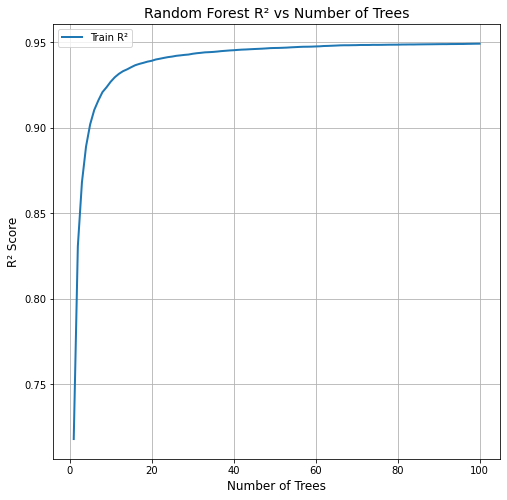


Results
----------------------------------------
Train MSE : 32.3798
Train R²  : 0.9491
Train RMSE : 5.6903
Test MSE  : 2928.4317
Test R²   : 0.4944
Test RMSE : 54.1150


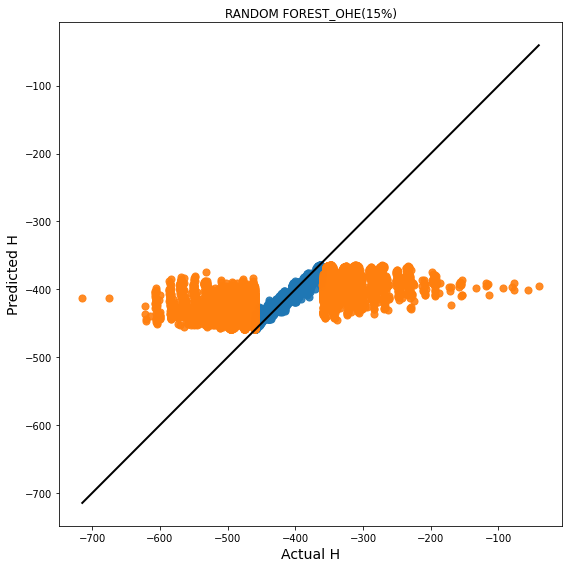


Training Fraction = 30%
Training Samples = 32704


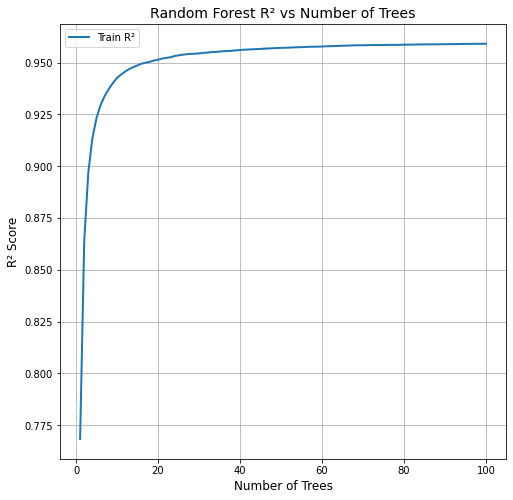


Results
----------------------------------------
Train MSE : 26.2359
Train R²  : 0.9591
Train RMSE : 5.1221
Test MSE  : 2664.6344
Test R²   : 0.5399
Test RMSE : 51.6201


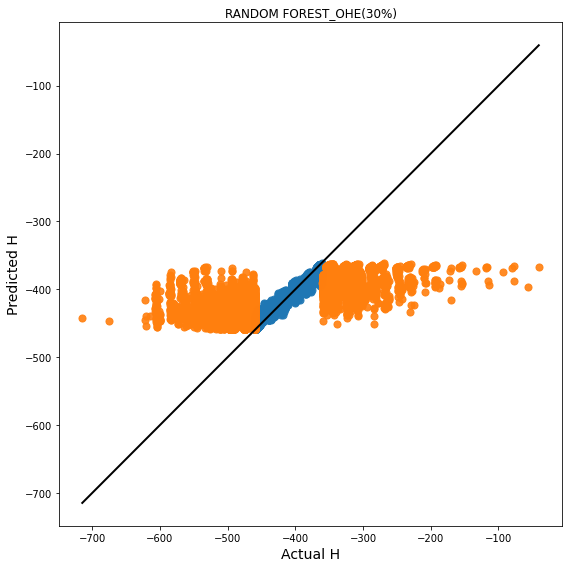


Training Fraction = 45%
Training Samples = 49057


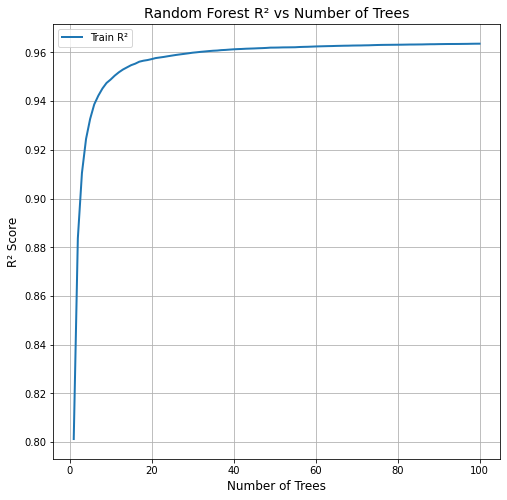


Results
----------------------------------------
Train MSE : 23.5178
Train R²  : 0.9636
Train RMSE : 4.8495
Test MSE  : 2563.8743
Test R²   : 0.5573
Test RMSE : 50.6347


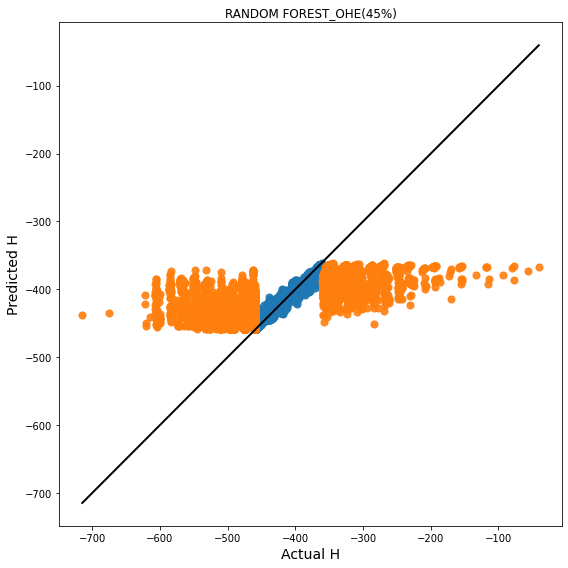


Training Fraction = 60%
Training Samples = 65409


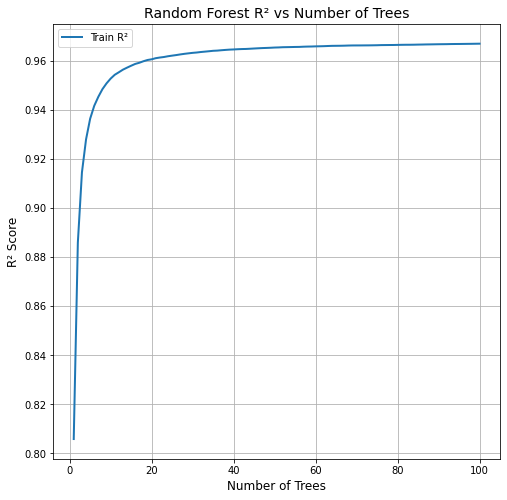


Results
----------------------------------------
Train MSE : 21.2065
Train R²  : 0.9670
Train RMSE : 4.6051
Test MSE  : 2505.1875
Test R²   : 0.5675
Test RMSE : 50.0518


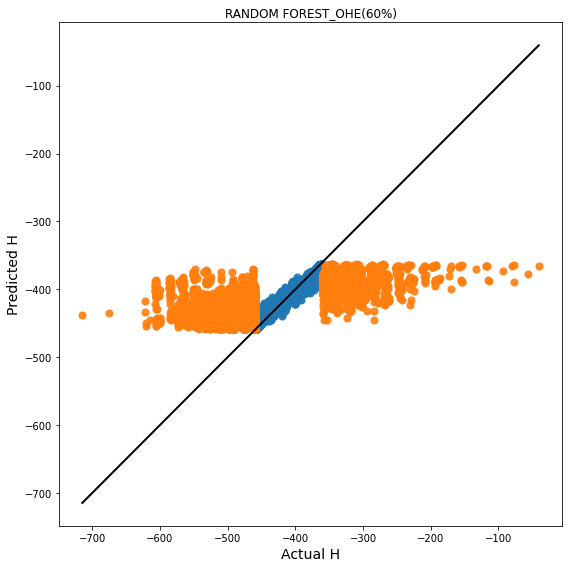


Training Fraction = 75%
Training Samples = 81762


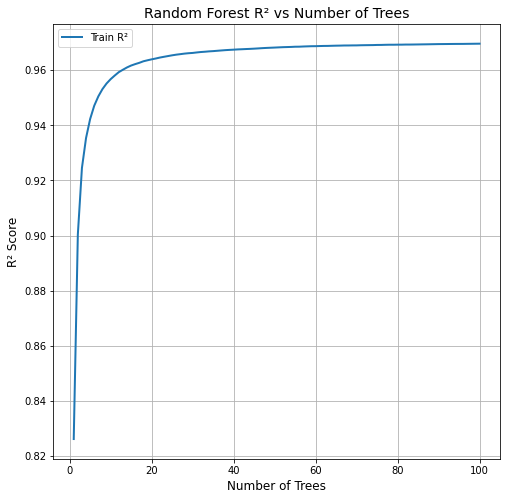


Results
----------------------------------------
Train MSE : 19.4990
Train R²  : 0.9696
Train RMSE : 4.4158
Test MSE  : 2462.6616
Test R²   : 0.5748
Test RMSE : 49.6252


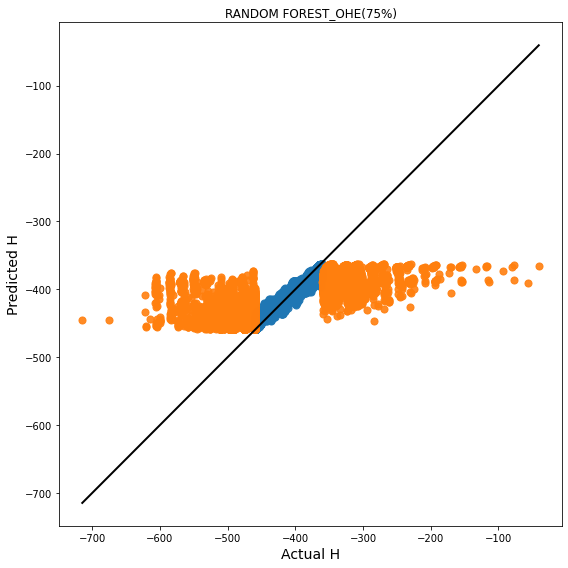


Training Fraction = 90%
Training Samples = 98114


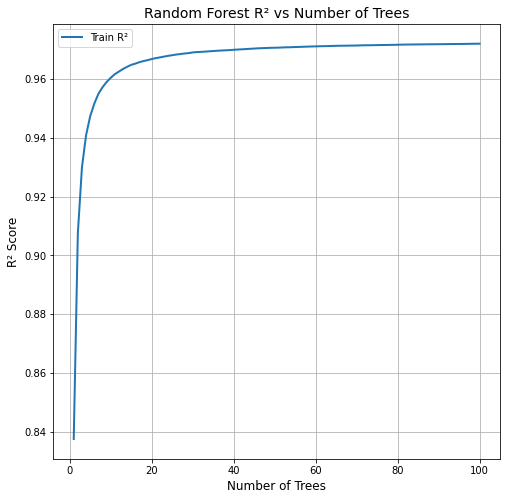


Results
----------------------------------------
Train MSE : 17.9439
Train R²  : 0.9721
Train RMSE : 4.2360
Test MSE  : 2436.9719
Test R²   : 0.5792
Test RMSE : 49.3657


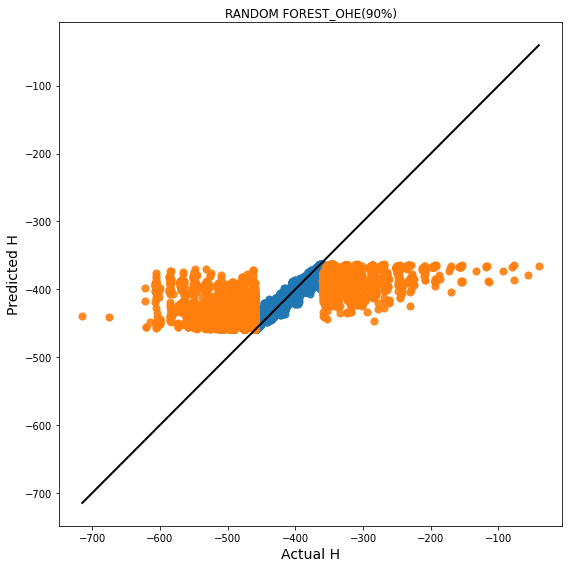

In [13]:
###########################################################
# OHE-RANDOM FOREST
# ===============================
# IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ===============================
# LOAD DATA
# ===============================
data = pd.read_csv("qm133885_properties.csv")

smiles = data["SMILES"].values
y = data["H"].values

# ===============================
# ONE-HOT ENCODING OF SMILES
# ===============================

# Character vocabulary
all_chars = sorted(set(''.join(smiles)))
char_to_int = {c:i for i,c in enumerate(all_chars)}

max_len = max(len(sm) for sm in smiles)
n_chars = len(all_chars)

print("Maximum SMILES length:", max_len)
print("Number of unique characters:", n_chars)

# Convert SMILES to OHE vectors
X = np.zeros((len(smiles), max_len * n_chars), dtype=np.uint8)

for i, sm in enumerate(smiles):
    for j, ch in enumerate(sm):
        X[i, j*n_chars + char_to_int[ch]] = 1

print("OHE Matrix Shape:", X.shape)

# ===============================
# EXTRAPOLATION SPLIT
# Train: H between -460 and -360
# Test: H > -360 & H < -460
# ===============================

train_mask = (y >= -460) & (y <= -360)
test_mask = ~train_mask

X_train_full = X[train_mask]
y_train_full = y[train_mask]

X_test_all = X[test_mask]
y_test_all = y[test_mask]

print("Training samples:", len(X_train_full))
print("Testing samples:", len(X_test_all))

#=================================
#FIX TEST SET TO 24869 SAMPLES
#==================================
np.random.seed(42)

test_indices = np.random.choice(len(X_test_all),size=24869,replace=False)

X_test = X_test_all[test_indices]
y_test = y_test_all[test_indices]

print("Fixed Test Sample:",len(X_test))

# ===============================
# TRAINING FRACTIONS
# ===============================

fractions = [0.15, 0.30, 0.45, 0.60, 0.75, 0.90]

for frac in fractions:

    train_size = int(frac * len(X_train_full))
    np.random.default_rng(42)
    idx = np.random.choice(
        len(X_train_full),
        train_size,
        replace=False
    )
    X_train_sub = X_train_full[idx]
    y_train_sub = y_train_full[idx]

    print(f"\nTraining Fraction = {frac*100:.0f}%")
    print("Training Samples =", len(X_train_sub))

    X_train_scaled = X_train_sub
    X_test_scaled = X_test

    # ===============================
    # RANDOM FOREST REGRESSION
    # ===============================
    
    rf = RandomForestRegressor(
        n_estimators=1,
        random_state=42,
        warm_start=True,
        n_jobs=-1
    )

    train_r2_list = []
    test_r2_list = []

    for n_trees in range(1, 101):

        rf.set_params(n_estimators=n_trees)
        rf.fit(X_train_scaled, y_train_sub)

        y_pred_train_iter = rf.predict(X_train_scaled)
        y_pred_test_iter = rf.predict(X_test_scaled)

        train_r2 = r2_score(y_train_sub, y_pred_train_iter)
        test_r2 = r2_score(y_test, y_pred_test_iter)

        train_r2_list.append(train_r2)
        test_r2_list.append(test_r2)

    #=============================
    #PLOT OF R2 VS NUMBER OF TRESS
    #==============================

    plt.figure(figsize=(8,8))

    plt.plot(range(1,101),
             train_r2_list,
             label='Train R²',
             linewidth=2)
    plt.xlabel('Number of Trees', fontsize=12)
    plt.ylabel('R² Score', fontsize=12)
    plt.title('Random Forest R² vs Number of Trees', fontsize=14)
    plt.legend()
    plt.grid(True)
    plt.savefig(
    f"RF_R2_Curve_{int(frac*100)}.png", dpi=600, bbox_inches='tight')
    plt.show()

    y_pred_train = rf.predict(X_train_scaled)
    y_pred_test = rf.predict(X_test_scaled)

    mse_train = mean_squared_error(y_train_sub, y_pred_train)
    rmse_train = np.sqrt(mse_train)
    r2_train = r2_score(y_train_sub, y_pred_train)

    mse_test = mean_squared_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mse_test)
    r2_test = r2_score(y_test, y_pred_test)

    print("\nResults")
    print("-"*40)
    print(f"Train MSE : {mse_train:.4f}")
    print(f"Train R²  : {r2_train:.4f}")
    print(f"Train RMSE : {rmse_train:.4f}")
    print(f"Test MSE  : {mse_test:.4f}")
    print(f"Test R²   : {r2_test:.4f}")
    print(f"Test RMSE : {rmse_test:.4f}")

    #=================================
    #PARITY PLOT
    #===============================
    #TRAIN POINTS
    plt.figure(figsize=(8,8))

    plt.scatter(
        y_train_sub,
        y_pred_train,
        s=50,
        alpha=0.9
    )
    
    #TEST POINTS
    plt.scatter(
        y_test,
        y_pred_test,
        s=50,
        alpha=0.9
    )

    min_val = min(y_train_sub.min(), y_pred_train.min(),y_test.min(), y_pred_test.min())
    max_val = max(y_train_sub.max(), y_pred_train.max(),y_test.max(), y_pred_test.max())

    plt.plot([min_val, max_val],
         [min_val, max_val],
         'k-',
         linewidth=2)

    plt.xlabel('Actual H', fontsize=14)
    plt.ylabel('Predicted H', fontsize=14)
    plt.title(f'RANDOM FOREST_OHE({int(frac*100)}%)')
    plt.tight_layout()
    plt.savefig(f"OHE_RF_Parity_{int(frac*100)}.png",
            dpi=600,
            bbox_inches='tight')
    plt.show()

Started
(133885, 2048)
int64
success
Training range: -459.185274 to -360.000294
Testing range: -714.559209 to -40.475117
Training samples: 109016
Testing samples: 24869
Fixed Test Sample: 24869

Training Fraction = 15%
Training Samples = 16352


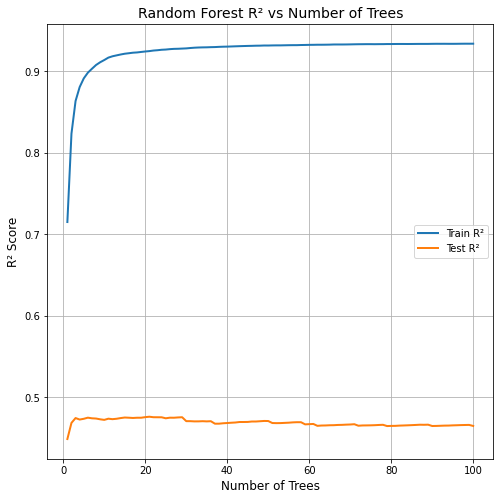


Results
----------------------------------------
Train MSE : 42.1533
Train R²  : 0.9338
Train RMSE : 6.4926
Test MSE  : 3099.6592
Test R²   : 0.4648
Test RMSE : 55.6746
Number of trees used= 100


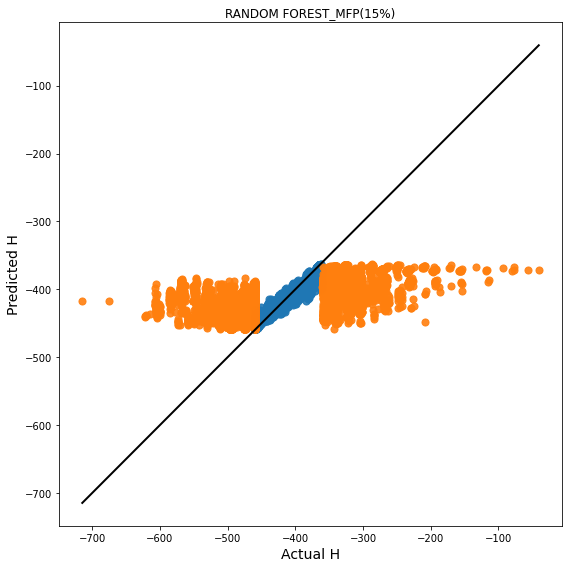

Best Tree = 21
Best Tree R2 = 0.4761428552455842

Training Fraction = 30%
Training Samples = 32704


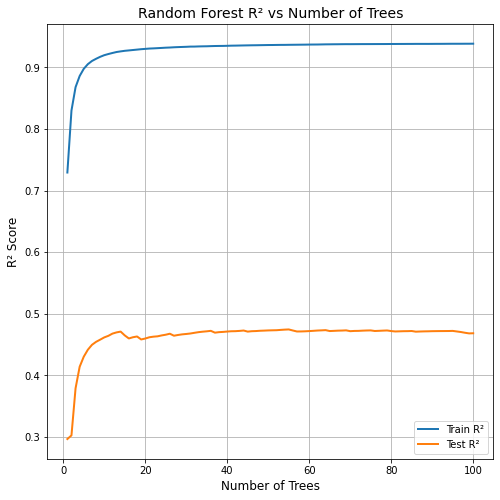


Results
----------------------------------------
Train MSE : 39.3931
Train R²  : 0.9387
Train RMSE : 6.2764
Test MSE  : 3079.7240
Test R²   : 0.4683
Test RMSE : 55.4953
Number of trees used= 100


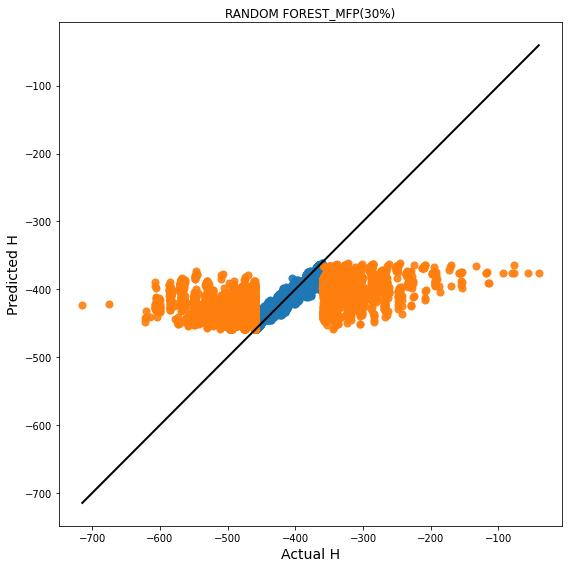

Best Tree = 55
Best Tree R2 = 0.4744824695442684

Training Fraction = 45%
Training Samples = 49057


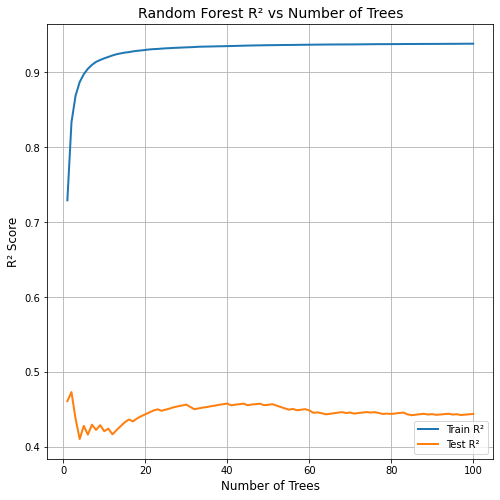


Results
----------------------------------------
Train MSE : 39.8605
Train R²  : 0.9383
Train RMSE : 6.3135
Test MSE  : 3218.1850
Test R²   : 0.4444
Test RMSE : 56.7290
Number of trees used= 100


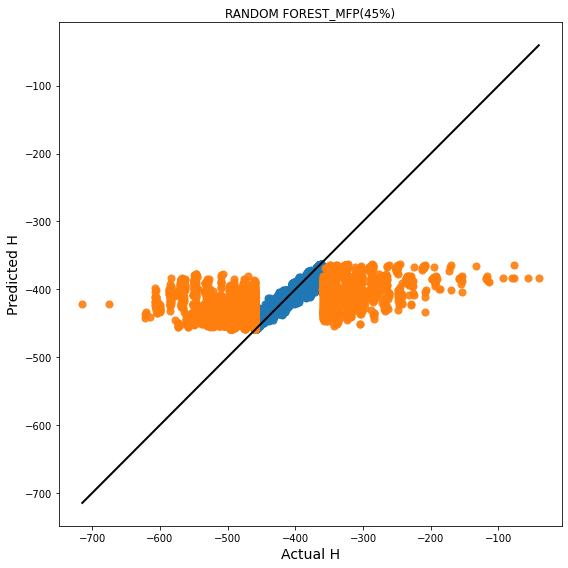

Best Tree = 2
Best Tree R2 = 0.4734697531154005

Training Fraction = 60%
Training Samples = 65409


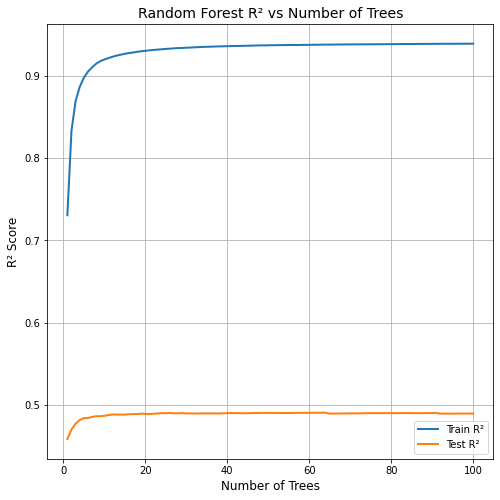


Results
----------------------------------------
Train MSE : 39.1645
Train R²  : 0.9390
Train RMSE : 6.2582
Test MSE  : 2956.0115
Test R²   : 0.4896
Test RMSE : 54.3692
Number of trees used= 100


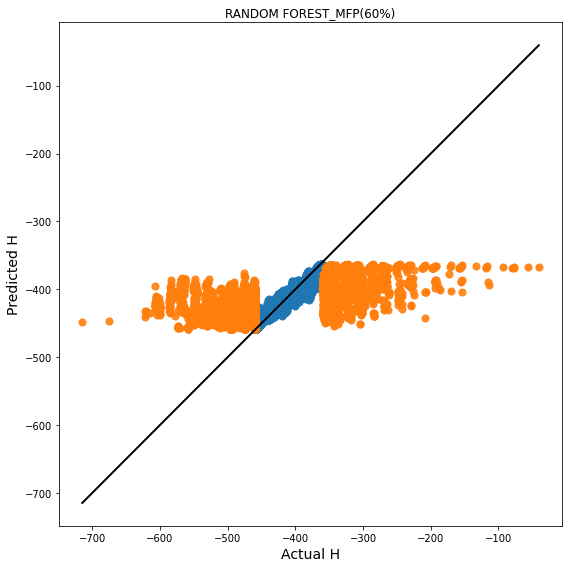

Best Tree = 64
Best Tree R2 = 0.49068087717014763

Training Fraction = 75%
Training Samples = 81762


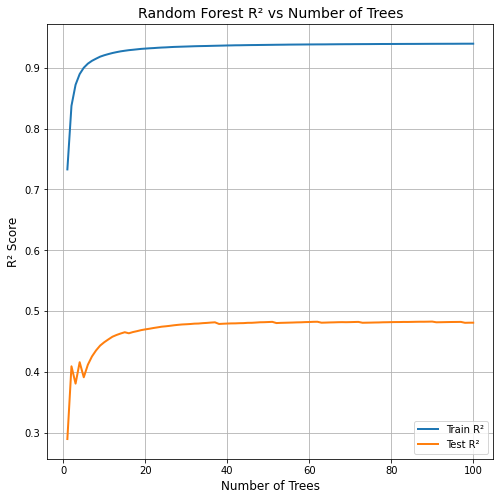


Results
----------------------------------------
Train MSE : 38.7378
Train R²  : 0.9396
Train RMSE : 6.2240
Test MSE  : 3006.1156
Test R²   : 0.4810
Test RMSE : 54.8281
Number of trees used= 100


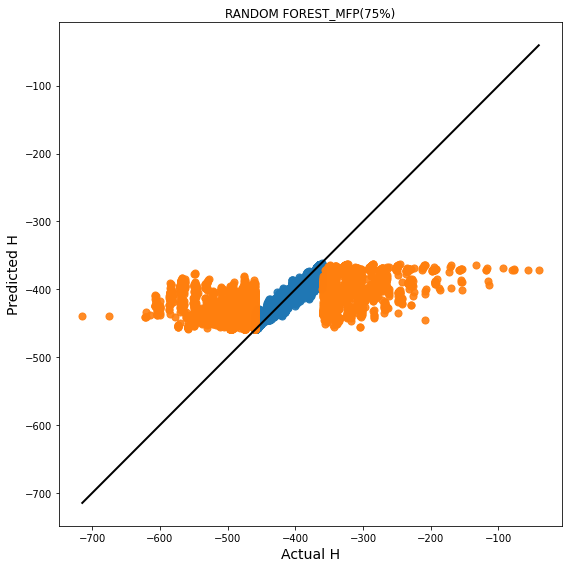

Best Tree = 90
Best Tree R2 = 0.4828089848377618

Training Fraction = 90%
Training Samples = 98114


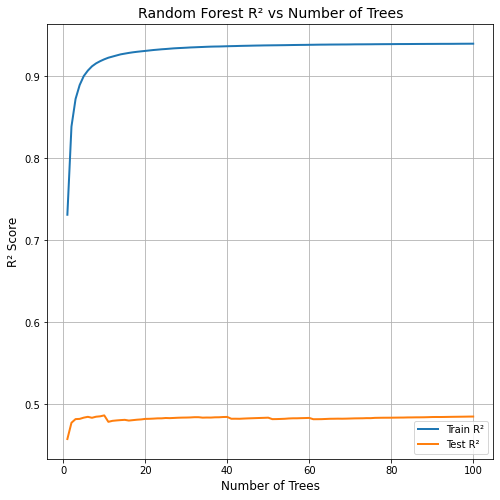


Results
----------------------------------------
Train MSE : 38.5826
Train R²  : 0.9399
Train RMSE : 6.2115
Test MSE  : 2981.2180
Test R²   : 0.4853
Test RMSE : 54.6005
Number of trees used= 100


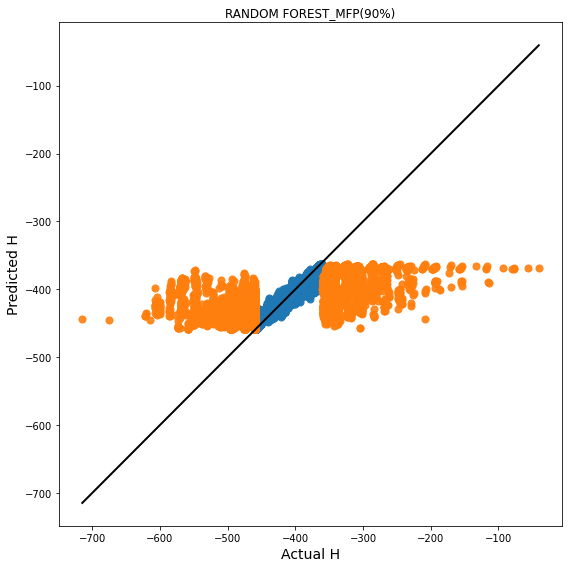

Best Tree = 10
Best Tree R2 = 0.4866900302495968


In [1]:
###########################################################
# MORGAN FINGERPRINT
# ===============================
# IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdFingerprintGenerator

# ===============================
# LOAD DATA
# ===============================
data = pd.read_csv("qm133885_properties.csv")
H = data["H"]
smiles = data["SMILES"].values
y = data["H"].values

print("Started")
# ===============================
# MORGAN FINGERPRINT OF SMILES
# ===============================

def smiles_to_fingerprint(smiles_string):
    mol = Chem.MolFromSmiles(smiles_string)
    if mol is None:
        return np.zeros((2048,), dtype=int)
    
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    return np.array(fp, dtype=int)

#Fingerprint Conversion
X = np.array([smiles_to_fingerprint(sm) for sm in smiles])
y = H.values

print(X.shape)
print(X.dtype)
print("success")

# ===============================
# EXTRAPOLATION SPLIT
# Train: H between -460 and -360
# Test: H > -360 & H < -460
# ===============================

train_mask = (y >= -460) & (y <= -360)
test_mask = ~train_mask

X_train_full = X[train_mask]
y_train_full = y[train_mask]

X_test_all = X[test_mask]
y_test_all = y[test_mask]

print("Training range:", y_train_full.min(), "to", y_train_full.max())
print("Testing range:", y_test_all.min(), "to", y_test_all.max())

print("Training samples:", len(X_train_full))
print("Testing samples:", len(X_test_all))

#=================================
#FIX TEST SET TO 24869 SAMPLES
#==================================
np.random.seed(42)

test_indices = np.random.choice(len(X_test_all),size=24869,replace=False)

X_test = X_test_all[test_indices]
y_test = y_test_all[test_indices]

print("Fixed Test Sample:",len(X_test))

# ===============================
# TRAINING FRACTIONS
# ===============================

fractions = [0.15, 0.30, 0.45, 0.60, 0.75, 0.90]

for frac in fractions:

    train_size = int(frac * len(X_train_full))
    np.random.default_rng(42)
    idx = np.random.choice(
        len(X_train_full),
        train_size,
        replace=False
    )
    X_train_sub = X_train_full[idx]
    y_train_sub = y_train_full[idx]

    print(f"\nTraining Fraction = {frac*100:.0f}%")
    print("Training Samples =", len(X_train_sub))

    X_train_scaled = X_train_sub
    X_test_scaled = X_test

    # ===============================
    # RANDOM FOREST REGRESSION
    # ===============================
    
    rf = RandomForestRegressor(
        n_estimators=1,
        random_state=42,
        warm_start=True,
        n_jobs=-1
    )

    train_r2_list = []
    test_r2_list = []

    for n_trees in range(1, 101):

        rf.set_params(n_estimators=n_trees)
        rf.fit(X_train_scaled, y_train_sub)

        y_pred_train_iter = rf.predict(X_train_scaled)
        y_pred_test_iter = rf.predict(X_test_scaled)

        train_r2 = r2_score(y_train_sub, y_pred_train_iter)
        test_r2 = r2_score(y_test, y_pred_test_iter)

        train_r2_list.append(train_r2)
        test_r2_list.append(test_r2)

    #=============================
    #PLOT OF R2 VS NUMBER OF TRESS
    #==============================

    plt.figure(figsize=(8,8))

    plt.plot(range(1,101),
             train_r2_list,
             label='Train R²',
             linewidth=2)
    
    plt.plot(range(1,101),
             test_r2_list,
             label='Test R²',
             linewidth=2)

    plt.xlabel('Number of Trees', fontsize=12)   
    plt.ylabel('R² Score', fontsize=12)
    plt.title('Random Forest R² vs Number of Trees', fontsize=14)
    plt.legend()
    plt.grid(True)
    plt.savefig(
    f"RF_R2__MFP_Curve_{int(frac*100)}.png", dpi=600, bbox_inches='tight')
    plt.show()
    
    y_pred_train = rf.predict(X_train_scaled)
    y_pred_test = rf.predict(X_test_scaled)

    mse_train = mean_squared_error(y_train_sub, y_pred_train)
    rmse_train = np.sqrt(mse_train)
    r2_train = r2_score(y_train_sub, y_pred_train)

    mse_test = mean_squared_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mse_test)
    r2_test = r2_score(y_test, y_pred_test)

    print("\nResults")
    print("-"*40)
    print(f"Train MSE : {mse_train:.4f}")
    print(f"Train R²  : {r2_train:.4f}")
    print(f"Train RMSE : {rmse_train:.4f}")
    print(f"Test MSE  : {mse_test:.4f}")
    print(f"Test R²   : {r2_test:.4f}")
    print(f"Test RMSE : {rmse_test:.4f}")

    rf.n_estimators
    print("Number of trees used=",rf.n_estimators)
    
    #=================================
    #PARITY PLOT
    #===============================
    plt.figure(figsize=(8,8))
    plt.scatter(
        y_train_sub,
        y_pred_train,
        s=50,
        alpha=0.9
    )
    plt.scatter(
        y_test,
        y_pred_test,
        s=50,
        alpha=0.9
    )

    min_val = min(y_train_sub.min(), y_pred_train.min(),y_test.min(), y_pred_test.min())
    max_val = max(y_train_sub.max(), y_pred_train.max(),y_test.max(), y_pred_test.max())

    plt.plot([min_val, max_val],
         [min_val, max_val],
         'k-',
         linewidth=2)

    plt.xlabel('Actual H', fontsize=14)
    plt.ylabel('Predicted H', fontsize=14)
    plt.title(f'RANDOM FOREST_MFP({int(frac*100)}%)')
    plt.tight_layout()

    plt.savefig(f"MPF_Parity_{int(frac*100)}.png",
            dpi=600,
            bbox_inches='tight')

    plt.show()
    
    #=========================
    #BEST TREE
    #==========================
    best_tree = np.argmax(test_r2_list)+1
    best_r2 = max(test_r2_list)
    print("Best Tree =", best_tree)
    print("Best Tree R2 =",best_r2)

In [ ]:
#MORGAN FINGERPRINT TUNING
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import ParameterGrid

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdFingerprintGenerator

# ===============================
# LOAD DATA
# ===============================
data = pd.read_csv("qm133885_properties.csv")
H = data["H"]

print("Started")

# ===============================
# MORGAN FP FUNCTION
# ===============================

def smiles_to_fp(smiles_string, radius, nBits):

    mol = Chem.MolFromSmiles(smiles_string)

    if mol is None:
        return np.zeros((nBits,), dtype=np.uint8)

    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius=radius,
        nBits=nBits
    )

    return np.array(fp, dtype=np.uint8)

# ===============================
# DATA
# ===============================

smiles = data["SMILES"].values
y = data["H"].values

# ===============================
# PARAMETER GRID
# ===============================

param_grid = {
    "radius": [1, 2, 3],
    "nBits": [4096],
    "n_estimators": [100, 200],
    "max_depth": [None],
}

results = []

best_r2 = -999
best_params = None

# ===============================
# GRID SEAR
# ===============================

for params in ParameterGrid(param_grid):

    print(f"\nTesting {params}")

    # Generate fingerprints
    X = np.array([
        smiles_to_fp(sm, params["radius"], params["nBits"])
        for sm in smiles
    ])

    # ===============================
    # EXTRAPOLATION SPLIT
    # ===============================

    train_mask = (y >= -460) & (y <= -360)
    test_mask = ~train_mask

    X_train = X[train_mask]
    y_train = y[train_mask]

    X_test = X[test_mask]
    y_test = y[test_mask]

    # ===============================
    # RANDOM FOREST
    # ===============================

    rf = RandomForestRegressor(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)

    test_r2 = r2_score(y_test, y_pred)

    print(f"Test R² = {test_r2:.4f}")

    results.append({
        **params,
        "test_r2": test_r2
    })

    if test_r2 > best_r2:
        best_r2 = test_r2
        best_params = params

# ===============================
# RESULTS
# ===============================

results_df = pd.DataFrame  

results_df = results_df.sort_values(
    by="test_r2",
    ascending=False
)

print("\nTop Results")
print(results_df.head())

print("\nBest Parameters:")
print(best_params)

print("\nBest Test R²:")
print(best_r2)

Started

Testing {'max_depth': None, 'nBits': 4096, 'n_estimators': 100, 'radius': 1}
Test R² = 0.4711

Testing {'max_depth': None, 'nBits': 4096, 'n_estimators': 100, 'radius': 2}
Test R² = 0.4840

Testing {'max_depth': None, 'nBits': 4096, 'n_estimators': 100, 'radius': 3}
Test R² = 0.4768

Testing {'max_depth': None, 'nBits': 4096, 'n_estimators': 200, 'radius': 1}
